In [747]:
# Libraries, modules
import soundfile as sf
import matplotlib.pyplot as plt
import os
import soundfile as sf
import numpy as np
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import hann
import cv2
from skimage.feature import peak_local_max

rec_filename = "005_902.896_seq.flac" #"000_1.392_seq.flac" "001_235.717_seq.flac" "002_340.336_seq.flac" "003_454.469_seq.flac" "004_675.269_seq.flac"

# Read full audio recording
data, fs = sf.read("./signal_sequences/"+rec_filename)
l_ch = data[:,0] # Left channel
#r_ch = data[:,1] # Right channel

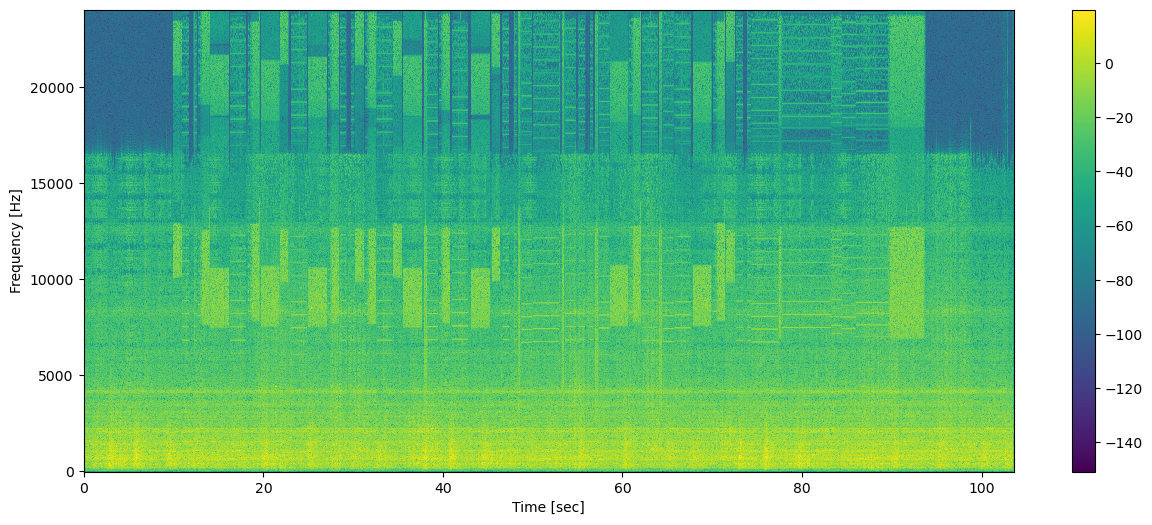

In [748]:
## Generate Spectrogram (2D FFT)

## Parameters
win_size = 2048  # Window size, 1024 to 4096 are ideal
hop_size = int(win_size*0.5)  # Overlap
fs = 48000  # Your sampling frequency
win = hann(win_size)

SFT = ShortTimeFFT(win, hop=hop_size, fs=fs) # Initialize ShortTimeFFT
Sx2 = SFT.spectrogram(l_ch) # Compute the spectrogram (absolute square of STFT)
Sx2[Sx2 == 0] = np.min(Sx2[np.nonzero(Sx2)]) # Substitute zeros with the minimum non-zero value to avoid log(0)
Sx2_dB = 10 * np.log10(Sx2) # Convert spectrogram to dB
t_min, t_max, f_min, f_max = SFT.extent(len(data), center_bins=True) # Get frequency and time boundaries
f_bins, t_bins = Sx2.shape # Get the number of frequency and time bins

# Plot the full spectrogram in dB
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins), np.linspace(f_min, f_max, f_bins), Sx2_dB)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

(253, 183)

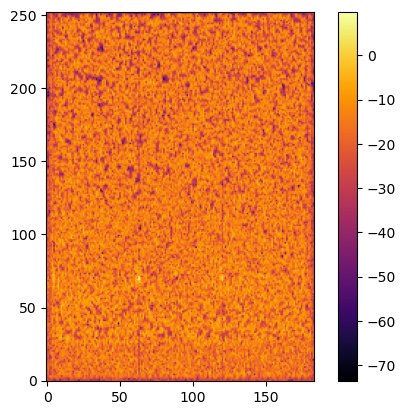

In [749]:
# Load end signal
endsig = np.genfromtxt('signal_samples/end_signal_48k-2048.csv', delimiter=',')

# Define end signal array
end_signal = endsig.astype(np.float32)
plt.imshow(end_signal, origin='lower', cmap="inferno")
plt.colorbar()
end_signal.shape

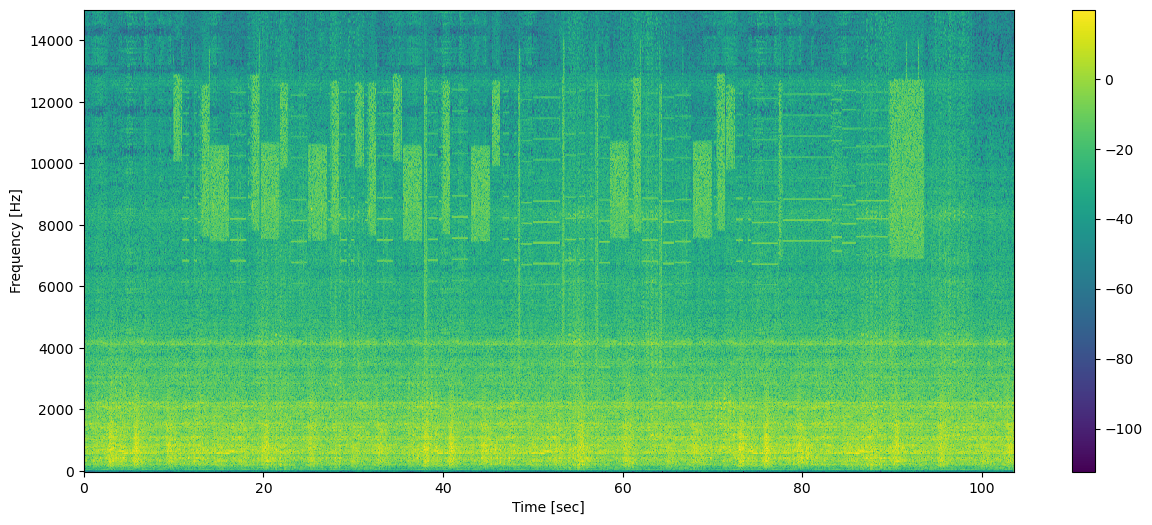

In [750]:
## Crop spectrogram
# Frequency range
f_low = 0  # Hz
f_high = 15000  # Hz
f_0 = int(f_low * f_bins / (f_max - f_min))
f_1 = int(f_high * f_bins / (f_max - f_min))

# Time range
t_start = t_min
t_end = t_max
t_0 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_start)
t_1 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_end)

# Crop the spectrogram to the selected frequency and time ranges
recording_crop = Sx2_dB[f_0:f_1, t_0:t_1]

# Plot the cropped spectrogram in dB
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

dtype('float32')

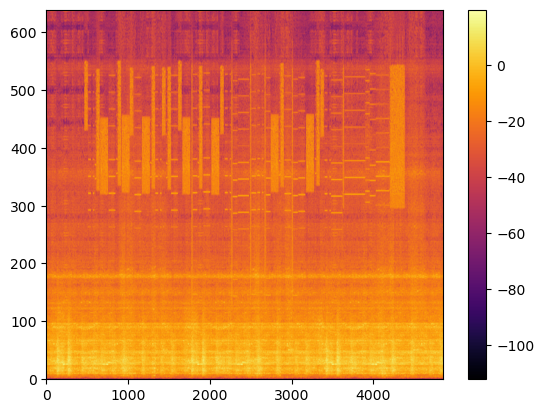

In [751]:
# Define recording array
recording = recording_crop.astype(np.float32)
plt.imshow(recording_crop, origin='lower', aspect='auto', cmap="inferno")
plt.colorbar()
recording.dtype

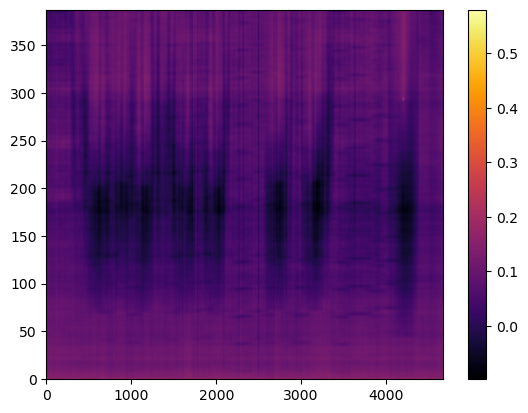

In [752]:
## Search based on OpenCV match template, very fast
correlation_opencv = cv2.matchTemplate(recording, end_signal, cv2.TM_CCOEFF_NORMED)

# Plot
plt.imshow(correlation_opencv, origin='lower', aspect='auto', cmap="inferno", vmin=np.min(correlation_opencv), vmax=np.max(correlation_opencv))
plt.colorbar()
plt.show()

In [753]:
## Find and print local maxima locations
dist = 1 #correlation_opencv.shape[0]//4
local_maxima = peak_local_max(correlation_opencv, min_distance=dist, threshold_abs=0.3)

# Stack the coordinates and values together in the desired format
local_maxima_with_values = np.hstack([local_maxima, correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]].reshape(-1, 1)])
for row in local_maxima_with_values:
    print(f"[{row[0]}, {row[1]}, {row[2]:.2f}]")

[293.0, 4205.0, 0.58]


In [754]:
## Determine time and frequency of each detected signal (lower left corner)

# Sort by time sample
sorted_indices = np.argsort(local_maxima[:, 1])
sorted_local_maxima = local_maxima[sorted_indices]

# Convert the local maxima indices to time and frequency values
detected_times = np.linspace(t_min, t_max, t_bins)[sorted_local_maxima[:, 1]]  # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[sorted_local_maxima[:, 0]]  # Frequency values from indices

# Print the detected times and frequencies
for time, freq in zip(detected_times, detected_freqs):
    print(f"Detected signal at Time: {time:.3f} seconds, Frequency: {freq:.1f} Hz")

Detected signal at Time: 89.714 seconds, Frequency: 6862.2 Hz


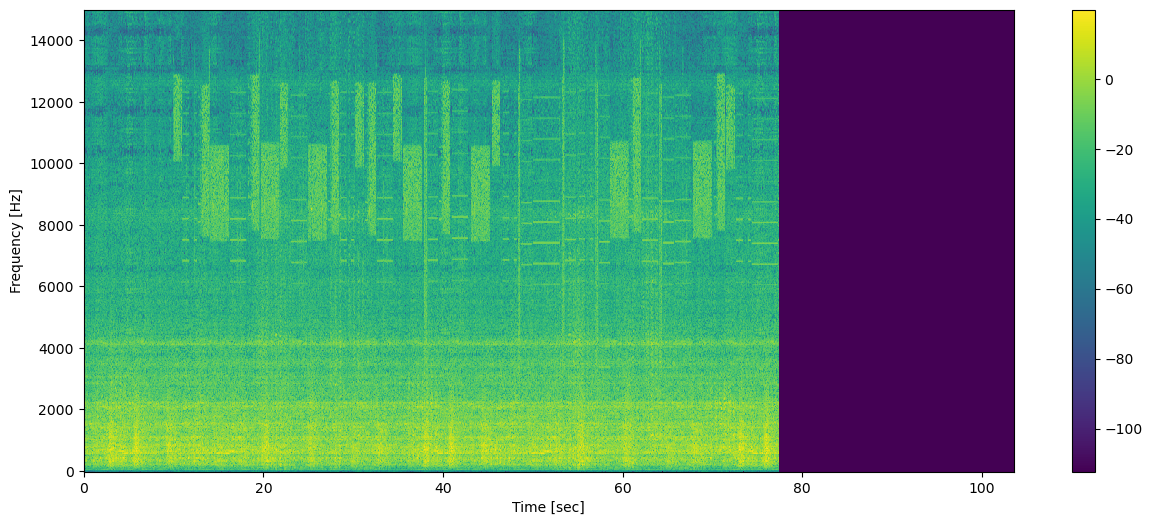

In [755]:
# Blank FFT values to the minimum (near 0) where end_signal occurs in recording_crop
# Define the width of the end_signal (in terms of time bins)
signal_time_width = end_signal.shape[1]  # Time range of end_signal (in time bins)
recording_crop_blank = recording_crop.copy()

# Modify the spectrogram based on local maxima
for local_max in sorted_local_maxima:
    t_index = local_max[1]  # Time index where end_signal occurs
    f_index = local_max[0]  # Frequency index where end_signal occurs
    
    # Set a region of the spectrogram around the detected location to the minimum value
    t_start_idx = max(0, t_index - (1520//2-end_signal.shape[1]))
    
    # Set **all** frequency bins for the detected time window to the minimum value
    recording_crop_blank[:, t_start_idx:] = np.min(recording_crop) #recording_crop_blank[:, t_start_idx:] - 50

# Plot the modified spectrogram
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

(253, 183)

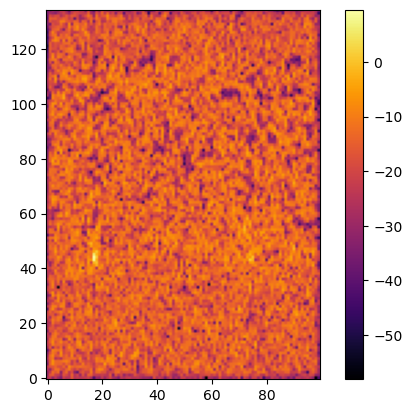

In [756]:
# Load G signal
Gsig = np.genfromtxt('signal_samples/G_signal_48k-2048.csv', delimiter=',')

# Define G signal array
G_signal = Gsig.astype(np.float32)
plt.imshow(G_signal, origin='lower', cmap="inferno")
plt.colorbar()
end_signal.shape

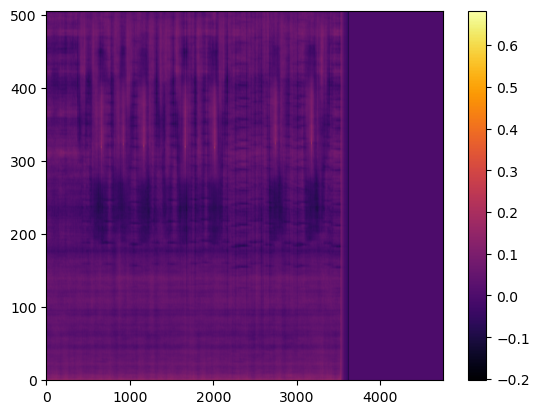

In [757]:
## Search based on OpenCV match template, very fast
recording_crop_blank = recording_crop_blank.astype(np.float32)
correlation_opencv = cv2.matchTemplate(recording_crop_blank, G_signal, cv2.TM_CCOEFF_NORMED)

# Plot
plt.imshow(correlation_opencv, origin='lower', aspect='auto', cmap="inferno", vmin=np.min(correlation_opencv), vmax=np.max(correlation_opencv))
plt.colorbar()
plt.show()

In [758]:
## Find and print local maxima locations
dist = 1 #correlation_opencv.shape[0]//4
local_maxima = peak_local_max(correlation_opencv, min_distance=dist, threshold_abs=0.3)

# Stack the coordinates and values together in the desired format
local_maxima_with_values = np.hstack([local_maxima, correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]].reshape(-1, 1)])
for row in local_maxima_with_values:
    print(f"[{row[0]}, {row[1]}, {row[2]:.2f}]")

[319.0, 1666.0, 0.68]
[318.0, 661.0, 0.66]
[322.0, 924.0, 0.58]
[320.0, 1171.0, 0.54]
[323.0, 3179.0, 0.51]
[318.0, 2020.0, 0.50]
[323.0, 2745.0, 0.48]


In [759]:
## Determine time and frequency of each detected signal (lower left corner)

# Sort by time sample
sorted_indices = np.argsort(local_maxima[:, 1])
sorted_local_maxima = local_maxima[sorted_indices]

# Convert the local maxima indices to time and frequency values
detected_times = np.linspace(t_min, t_max, t_bins)[sorted_local_maxima[:, 1]]  # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[sorted_local_maxima[:, 0]]  # Frequency values from indices

# Print the detected times and frequencies
for time, freq in zip(detected_times, detected_freqs):
    print(f"Detected signal at Time: {time:.3f} seconds, Frequency: {freq:.1f} Hz")

Detected signal at Time: 14.094 seconds, Frequency: 7448.7 Hz
Detected signal at Time: 19.705 seconds, Frequency: 7542.5 Hz
Detected signal at Time: 24.976 seconds, Frequency: 7495.6 Hz
Detected signal at Time: 35.538 seconds, Frequency: 7472.1 Hz
Detected signal at Time: 43.092 seconds, Frequency: 7448.7 Hz
Detected signal at Time: 58.561 seconds, Frequency: 7566.0 Hz
Detected signal at Time: 67.822 seconds, Frequency: 7566.0 Hz


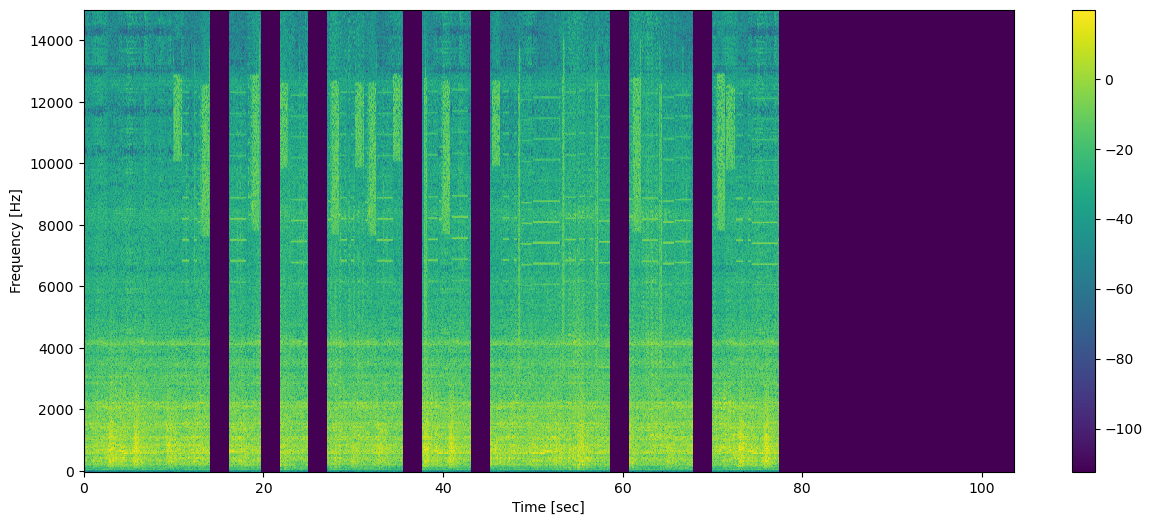

In [760]:
# Blank FFT values to the minimum (near 0) where end_signal occurs in recording_crop
signal_time_width = G_signal.shape[1]  # Time range of end_signal (in time bins)
recording_crop_blank_G = recording_crop_blank.copy()

# Modify the spectrogram based on local maxima
for local_max in sorted_local_maxima:
    t_index = local_max[1]  # Time index where end_signal occurs
    f_index = local_max[0]  # Frequency index where end_signal occurs
    
    # Set a region of the spectrogram around the detected location to the minimum value
    t_start_idx = max(0, t_index)
    t_end_idx = min(t_bins, t_index + signal_time_width)
    
    # Set **all** frequency bins for the detected time window to the minimum value
    recording_crop_blank_G[:, t_start_idx:t_end_idx] = np.min(recording_crop)

# Plot the modified spectrogram
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_G)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

(253, 183)

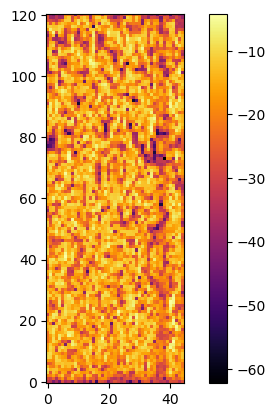

In [761]:
# Load F signal
Fsig = np.genfromtxt('signal_samples/F_signal_48k-2048.csv', delimiter=',')

# Define end signal array
F_signal = Fsig.astype(np.float32)
plt.imshow(F_signal, origin='lower', cmap="inferno")
plt.colorbar()
end_signal.shape

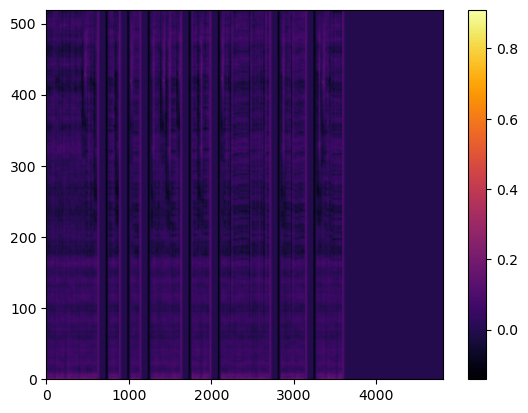

In [762]:
## Search based on OpenCV match template, very fast
recording_crop_blank_G = recording_crop_blank_G.astype(np.float32)
correlation_opencv = cv2.matchTemplate(recording_crop_blank_G, F_signal, cv2.TM_CCOEFF_NORMED)

# Plot
plt.imshow(correlation_opencv, origin='lower', aspect='auto', cmap="inferno", vmin=np.min(correlation_opencv), vmax=np.max(correlation_opencv))
plt.colorbar()
plt.show()

In [763]:
## Find and print local maxima locations
dist = 1 #correlation_opencv.shape[0]//4
local_maxima = peak_local_max(correlation_opencv, min_distance=dist, threshold_abs=0.3)

# Stack the coordinates and values together in the desired format
local_maxima_with_values = np.hstack([local_maxima, correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]].reshape(-1, 1)])
for row in local_maxima_with_values:
    print(f"[{row[0]}, {row[1]}, {row[2]:.2f}]")

[422.0, 2130.0, 0.91]
[419.0, 1024.0, 0.82]
[419.0, 1418.0, 0.67]
[429.0, 468.0, 0.64]
[417.0, 3355.0, 0.63]
[430.0, 1615.0, 0.53]


In [764]:
## Determine time and frequency of each detected signal (lower left corner)

# Sort by time sample
sorted_indices = np.argsort(local_maxima[:, 1])
sorted_local_maxima = local_maxima[sorted_indices]

# Convert the local maxima indices to time and frequency values
detected_times = np.linspace(t_min, t_max, t_bins)[sorted_local_maxima[:, 1]]  # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[sorted_local_maxima[:, 0]]  # Frequency values from indices

# Print the detected times and frequencies
for time, freq in zip(detected_times, detected_freqs):
    print(f"Detected signal at Time: {time:.3f} seconds, Frequency: {freq:.1f} Hz")

Detected signal at Time: 9.975 seconds, Frequency: 10052.8 Hz
Detected signal at Time: 21.839 seconds, Frequency: 9818.2 Hz
Detected signal at Time: 30.246 seconds, Frequency: 9818.2 Hz
Detected signal at Time: 34.450 seconds, Frequency: 10076.2 Hz
Detected signal at Time: 45.439 seconds, Frequency: 9888.6 Hz
Detected signal at Time: 71.577 seconds, Frequency: 9771.3 Hz


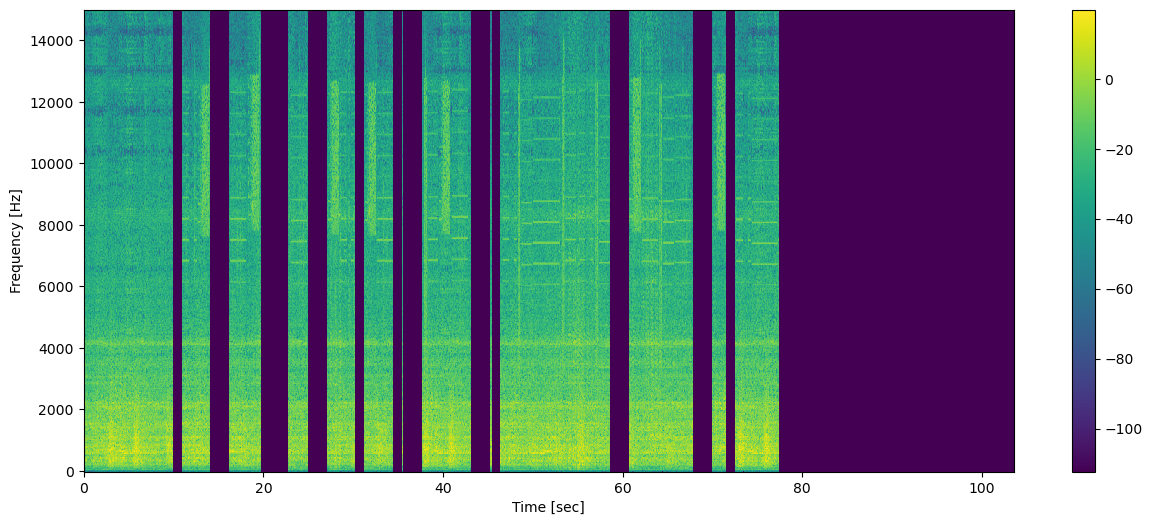

In [765]:
# Blank FFT values to the minimum (near 0) where end_signal occurs in recording_crop
# Define the width of the end_signal (in terms of time bins)
signal_time_width = F_signal.shape[1]  # Time range of end_signal (in time bins)
recording_crop_blank_F = recording_crop_blank_G.copy()

# Modify the spectrogram based on local maxima
for local_max in sorted_local_maxima:
    t_index = local_max[1]  # Time index where end_signal occurs
    f_index = local_max[0]  # Frequency index where end_signal occurs
    
    # Set a region of the spectrogram around the detected location to the minimum value
    t_start_idx = max(0, t_index)
    t_end_idx = min(t_bins, t_index + signal_time_width)
    
    # Set **all** frequency bins for the detected time window to the minimum value
    recording_crop_blank_F[:, t_start_idx:t_end_idx] = np.min(recording_crop)

# Plot the modified spectrogram
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_F)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

(253, 183)

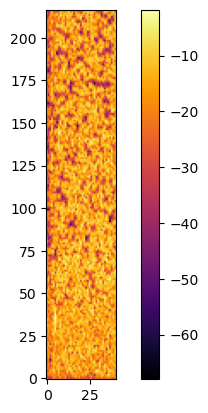

In [766]:
# Load E signal
Esig = np.genfromtxt('signal_samples/E_signal_48k-2048.csv', delimiter=',')

# Define end signal array
E_signal = Esig.astype(np.float32)
plt.imshow(E_signal, origin='lower', cmap="inferno")
plt.colorbar()
end_signal.shape

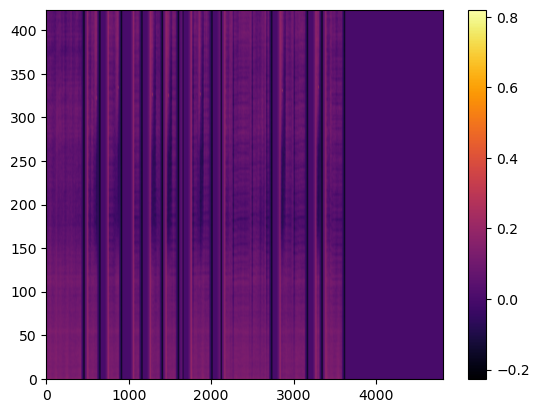

In [767]:
## Search based on OpenCV match template, very fast
recording_crop = recording_crop.astype(np.float32)
correlation_opencv = cv2.matchTemplate(recording_crop_blank_F, E_signal, cv2.TM_CCOEFF_NORMED)

# Plot
plt.imshow(correlation_opencv, origin='lower', aspect='auto', cmap="inferno", vmin=np.min(correlation_opencv), vmax=np.max(correlation_opencv))
plt.colorbar()
plt.show()

In [768]:
## Find and print local maxima locations
dist = 1 #correlation_opencv.shape[0]//4
local_maxima = peak_local_max(correlation_opencv, min_distance=dist, threshold_abs=0.3)

# Stack the coordinates and values together in the desired format
local_maxima_with_values = np.hstack([local_maxima, correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]].reshape(-1, 1)])
for row in local_maxima_with_values:
    print(f"[{row[0]}, {row[1]}, {row[2]:.2f}]")

[330.0, 2866.0, 0.82]
[334.0, 876.0, 0.80]
[326.0, 1872.0, 0.66]
[334.0, 3306.0, 0.64]
[326.0, 1292.0, 0.63]
[325.0, 1486.0, 0.57]
[322.0, 615.0, 0.50]


In [769]:
## Determine time and frequency of each detected signal (lower left corner)

# Sort by time sample
sorted_indices = np.argsort(local_maxima[:, 1])
sorted_local_maxima = local_maxima[sorted_indices]

# Convert the local maxima indices to time and frequency values
detected_times = np.linspace(t_min, t_max, t_bins)[sorted_local_maxima[:, 1]]  # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[sorted_local_maxima[:, 0]]  # Frequency values from indices

# Print the detected times and frequencies
for time, freq in zip(detected_times, detected_freqs):
    print(f"Detected signal at Time: {time:.3f} seconds, Frequency: {freq:.1f} Hz")

Detected signal at Time: 13.112 seconds, Frequency: 7542.5 Hz
Detected signal at Time: 18.681 seconds, Frequency: 7824.1 Hz
Detected signal at Time: 27.558 seconds, Frequency: 7636.4 Hz
Detected signal at Time: 31.697 seconds, Frequency: 7612.9 Hz
Detected signal at Time: 39.934 seconds, Frequency: 7636.4 Hz
Detected signal at Time: 61.143 seconds, Frequency: 7730.2 Hz
Detected signal at Time: 70.532 seconds, Frequency: 7824.1 Hz


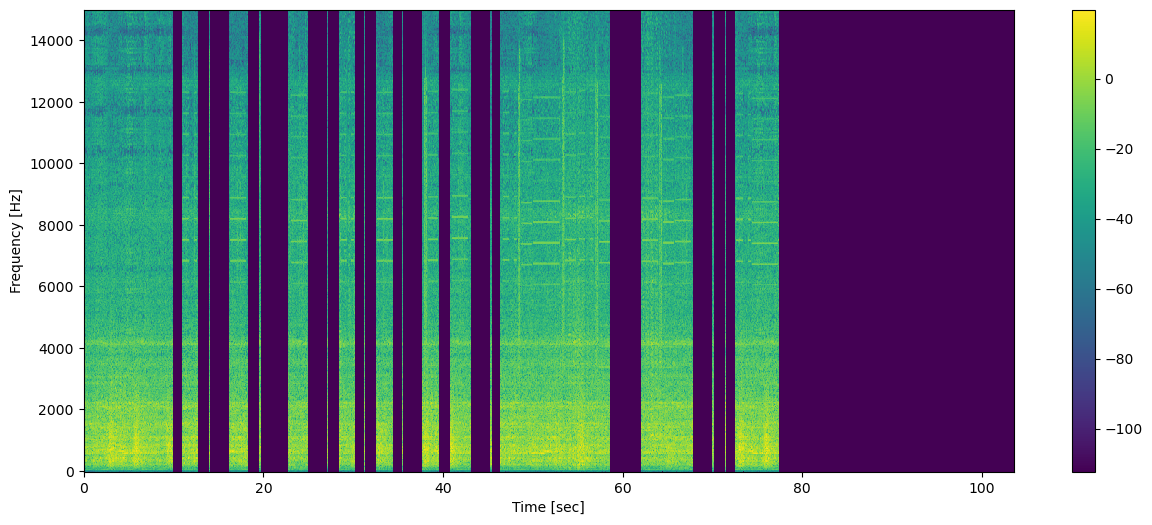

In [770]:
# Blank FFT values to the minimum (near 0) where end_signal occurs in recording_crop
# Define the width of the end_signal (in terms of time bins)
signal_time_width = E_signal.shape[1]  # Time range of end_signal (in time bins)
recording_crop_blank_E = recording_crop_blank_F.copy()

# Modify the spectrogram based on local maxima
for local_max in sorted_local_maxima:
    t_index = local_max[1]  # Time index where end_signal occurs
    f_index = local_max[0]  # Frequency index where end_signal occurs
    
    # Set a region of the spectrogram around the detected location to the minimum value
    t_start_idx = max(0, t_index - (59-E_signal.shape[1]))
    t_end_idx = min(t_bins, t_index + signal_time_width)
    
    # Set **all** frequency bins for the detected time window to the minimum value
    recording_crop_blank_E[:, t_start_idx:t_end_idx] = np.min(recording_crop)

# Plot the modified spectrogram
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_E)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

(253, 183)

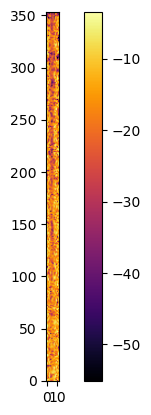

In [771]:
# Load D signal
Dsig = np.genfromtxt('signal_samples/D_signal_48k-2048.csv', delimiter=',')

# Define end signal array
D_signal = Dsig.astype(np.float32)
plt.imshow(D_signal, origin='lower', cmap="inferno")
plt.colorbar()
end_signal.shape

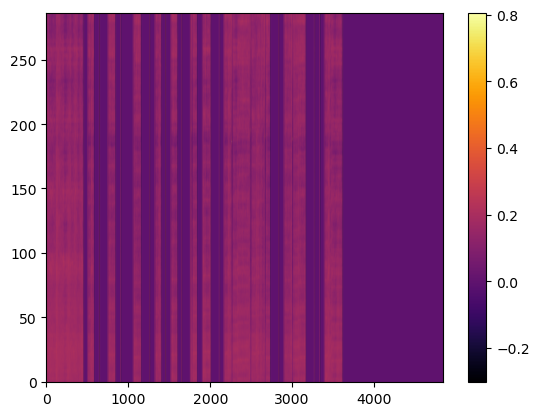

In [772]:
## Search based on OpenCV match template, very fast
recording_crop_blank_E = recording_crop_blank_E.astype(np.float32)
correlation_opencv = cv2.matchTemplate(recording_crop_blank_E, D_signal, cv2.TM_CCOEFF_NORMED)

# Plot
plt.imshow(correlation_opencv, origin='lower', aspect='auto', cmap="inferno", vmin=np.min(correlation_opencv), vmax=np.max(correlation_opencv))
plt.colorbar()
plt.show()

In [773]:
## Find and print local maxima locations
dist = 1 #correlation_opencv.shape[0]//4
local_maxima = peak_local_max(correlation_opencv, min_distance=dist, threshold_abs=0.3)

# Stack the coordinates and values together in the desired format
local_maxima_with_values = np.hstack([local_maxima, correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]].reshape(-1, 1)])
for row in local_maxima_with_values:
    print(f"[{row[0]}, {row[1]}, {row[2]:.2f}]")

[186.0, 2266.0, 0.81]
[188.0, 3005.0, 0.70]
[190.0, 2671.0, 0.55]
[195.0, 2496.0, 0.47]
[196.0, 1778.0, 0.47]


In [774]:
## Determine time and frequency of each detected signal (lower left corner)

# Sort by time sample
sorted_indices = np.argsort(local_maxima[:, 1])
sorted_local_maxima = local_maxima[sorted_indices]

# Convert the local maxima indices to time and frequency values
detected_times = np.linspace(t_min, t_max, t_bins)[sorted_local_maxima[:, 1]]  # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[sorted_local_maxima[:, 0]]  # Frequency values from indices

# Print the detected times and frequencies
for time, freq in zip(detected_times, detected_freqs):
    print(f"Detected signal at Time: {time:.3f} seconds, Frequency: {freq:.1f} Hz")

Detected signal at Time: 37.928 seconds, Frequency: 4586.5 Hz
Detected signal at Time: 48.341 seconds, Frequency: 4351.9 Hz
Detected signal at Time: 53.248 seconds, Frequency: 4563.1 Hz
Detected signal at Time: 56.982 seconds, Frequency: 4445.8 Hz
Detected signal at Time: 64.109 seconds, Frequency: 4398.8 Hz


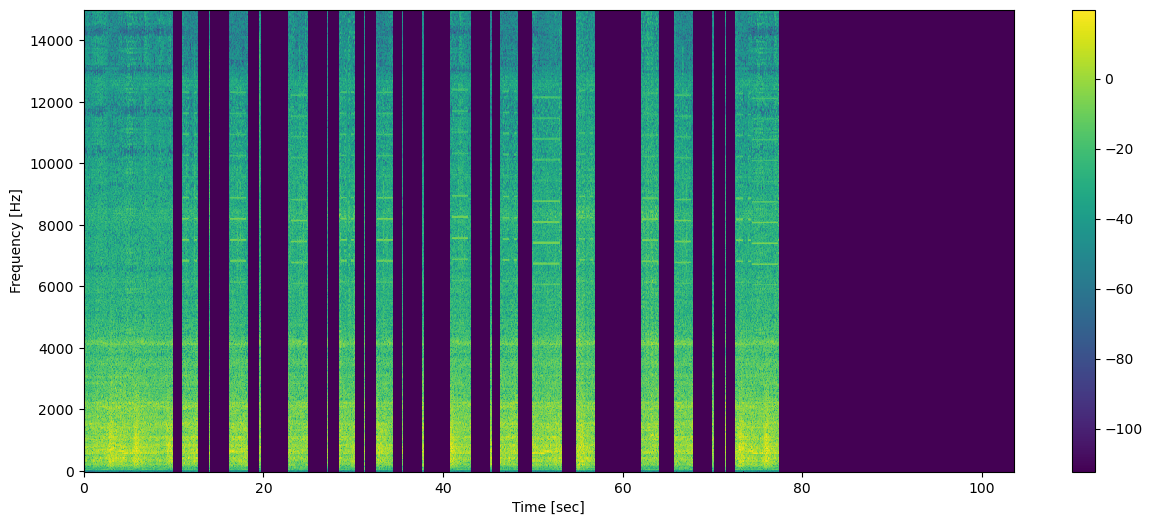

In [775]:
# Blank FFT values to the minimum (near 0) where end_signal occurs in recording_crop
# Define the width of the end_signal (in terms of time bins)
signal_time_width = D_signal.shape[1]  # Time range of end_signal (in time bins)
recording_crop_blank_D = recording_crop_blank_E.copy()

# Modify the spectrogram based on local maxima
for local_max in sorted_local_maxima:
    t_index = local_max[1]  # Time index where end_signal occurs
    f_index = local_max[0]  # Frequency index where end_signal occurs
    
    # Set a region of the spectrogram around the detected location to the minimum value
    t_start_idx = max(0, t_index)
    t_end_idx = min(t_bins, t_index + 75)
    
    # Set **all** frequency bins for the detected time window to the minimum value
    recording_crop_blank_D[:, t_start_idx:t_end_idx] = np.min(recording_crop)

# Plot the modified spectrogram
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_D)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [776]:
# Spectrogram bandpass filter
def spec_bandpass(spec, f_max, f_bins, f_low, f_high):
    f_bl = int(f_low/f_max*f_bins) # Low frequency bin
    f_bh = int(f_high/f_max*f_bins) # High frequency bin
    return spec[f_bl:f_bh,:]

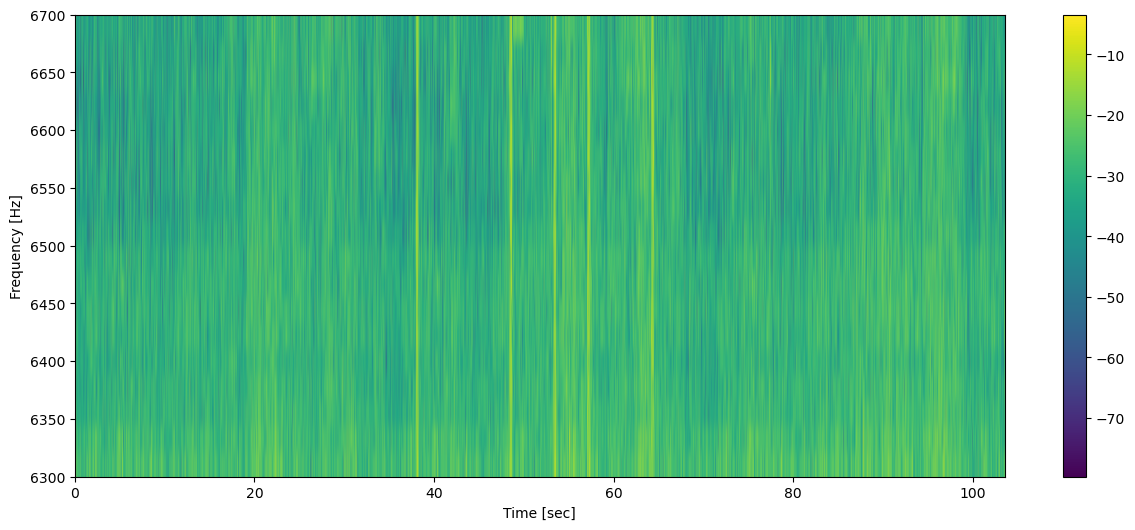

mean -30.5965555647368
std 7.587458824419759


In [777]:
## Measure background noise level
noise = spec_bandpass(Sx2_dB, f_max, f_bins, 6300, 6700)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(noise, origin='lower', aspect='auto', extent=[t_min, t_max, 6300, 6700])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

noise_mean = np.mean(noise)
noise_std = np.std(noise)
print("mean " + str(noise_mean))
print("std " + str(noise_std))

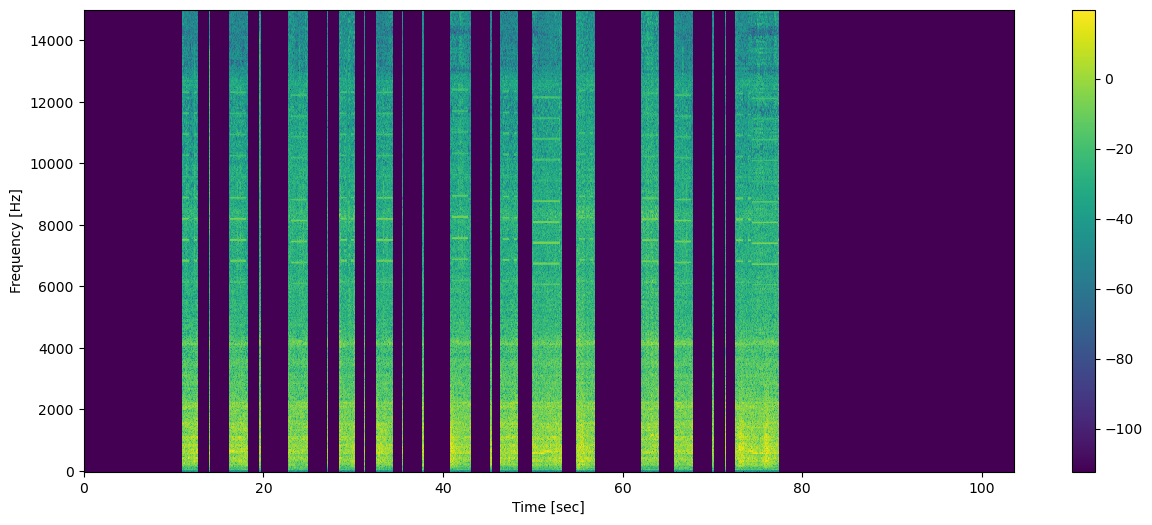

In [778]:
## More blanking before detecting "tones"
recording_crop_blank_pre_tone = recording_crop_blank_D.copy()

# Blank first 9.9 s
recording_crop_blank_pre_tone[:, 0:int(fs/2048*2*9.9)] = np.min(recording_crop)

# Plot the modified spectrogram
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_pre_tone)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

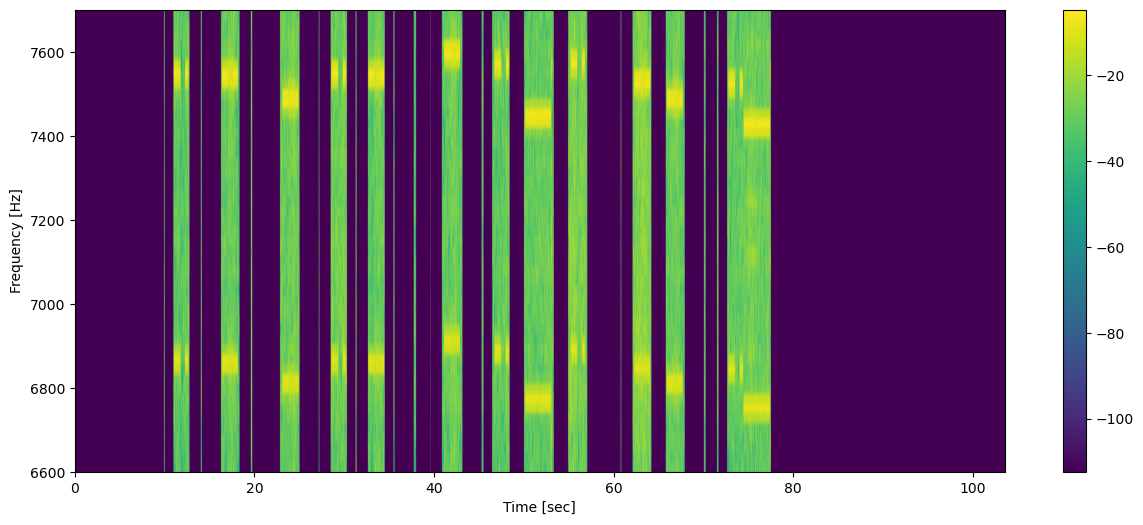

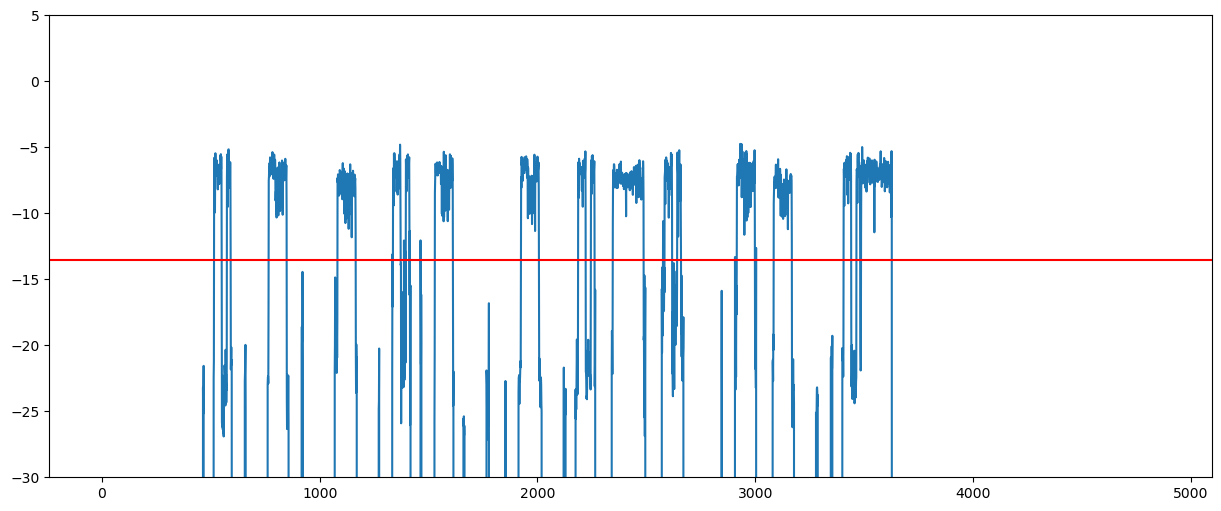

In [779]:
## Measure signal level in strong "tone" band

f_low = 6600
f_high = 7700

sig_low = spec_bandpass(recording_crop_blank_pre_tone, f_max, f_bins, f_low, f_high)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(sig_low, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

sig_level_l = np.max(sig_low, axis=0)

plt.figure(figsize=(15,6))
plt.plot(sig_level_l)
plt.axhline(y = noise_mean + noise_std*2.25, color = 'r', linestyle = '-')
plt.ylim(-30, 5)

plt.show()

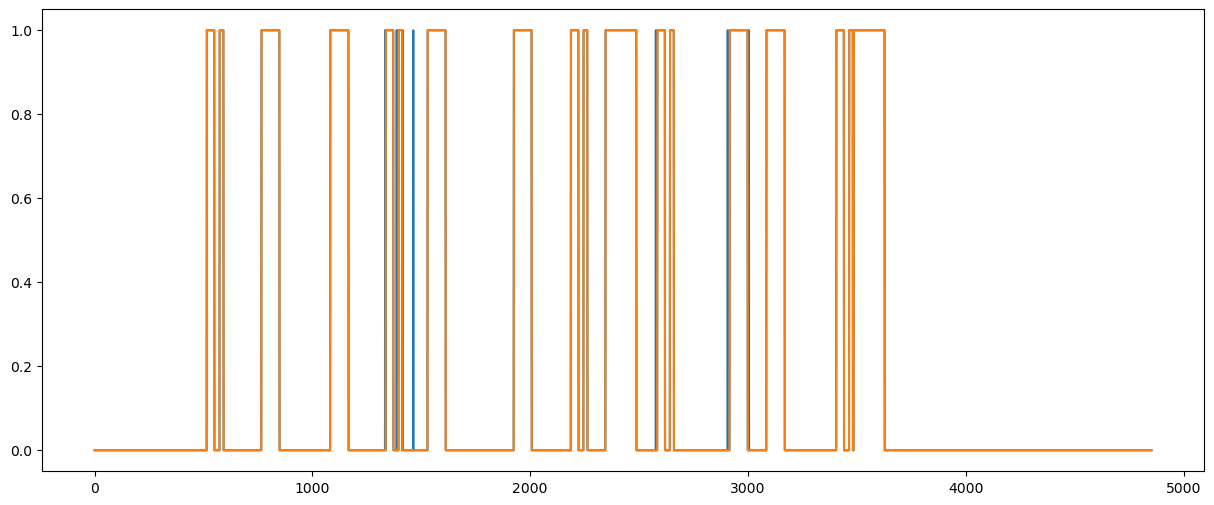

In [780]:
## Create "detection" array
threshold = noise_mean + noise_std*2.25 # Threshold level to detect a signal
above_threshold = (sig_level_l > threshold).astype(int) # Array of detections (1) and non-detections (0)

# Function to remove short detections
def remove_short_ones(arr, min_ones):
    result = arr.copy()
    i = 0
    while i < len(result):
        if result[i] == 1:  # Found the start of a sequence of 1s
            start = i
            while i < len(result) and result[i] == 1:  # Find the end of this sequence
                i += 1
            end = i
            if end - start < min_ones:  # If the length of the sequence is shorter than min_ones, set to 0
                for j in range(start, end):
                    result[j] = 0
        else:
            i += 1    
    return result

min_ones = int(fs/win_size*2*0.2) # 0.2 seconds, the shortest portion of signal C is 0.38 s long
sig_detected = remove_short_ones(above_threshold, min_ones)
plt.figure(figsize=(15,6))
plt.plot(above_threshold)
plt.plot(sig_detected)
plt.show()

In [781]:
## Detect tone signals
def detect_tone_signals(bin_list):
    sequences = []
    start_idx = None    
    for i, num in enumerate(bin_list): # Go through detection array
        if num == 1:
            if start_idx is None:  # Beginning of a new sequence of 1s
                start_idx = i
        elif num == 0 and start_idx is not None:  # End the sequence when we hit a 0 after detecting 1s
            sequences.append((start_idx, i - 1))  # End of sequence
            start_idx = None    
    if start_idx is not None:     # If we end with a sequence of 1s and it's still open, close it
        sequences.append((start_idx, len(bin_list) - 1))    
    return sequences

sequences = detect_tone_signals(sig_detected)

for seq in sequences:
    print(str(seq) + " " + str(seq[1] - seq[0]))

(515, 549) 34
(574, 591) 17
(766, 848) 82
(1082, 1165) 83
(1337, 1371) 34
(1395, 1412) 17
(1529, 1611) 82
(1925, 2006) 81
(2187, 2221) 34
(2245, 2262) 17
(2346, 2487) 141
(2584, 2618) 34
(2642, 2659) 17
(2916, 2998) 82
(3085, 3168) 83
(3406, 3440) 34
(3465, 3481) 16
(3486, 3627) 141


In [782]:
def detect_tones(sequences):
    tones = []  # List with final output
    i = 0  # Initialize row index
    while i < len(sequences):  # Use while loop to allow manual control of index
        duration_samples = sequences[i][1] - sequences[i][0]  # Duration of each sequence, in samples
        row = [sequences[i][0], sequences[i][1], duration_samples, ""]  # Add duration as 3rd column

        if duration_samples > 115: # Tone A is usually > 130 samples
            row[3] = "A"
        elif duration_samples > 65: # Tone B is usually > 80 samples
            row[3] = "B"
        elif duration_samples > 25: # Tone C is made of two tones, the first is usually > 33 samples
            if i + 1 < len(sequences):  # Check if there is a next row
                next_duration_samples = sequences[i + 1][1] - sequences[i + 1][0]
                if next_duration_samples < 20:  # The second tone is usually < 17 samples
                    # Merge rows and add "C" label
                    merged_first_column = sequences[i][0]
                    merged_second_column = sequences[i + 1][1]
                    merged_duration_samples = merged_second_column - merged_first_column
                    tones.append([merged_first_column, merged_second_column, merged_duration_samples, "C"])
                    i += 2  # Skip the next row as it was merged with the current one
                    continue  # Skip current row because it's merged with the next row
                else:
                    raise ValueError("C tone only partially detected (missing 2nd half).")
            else:
                raise ValueError("C tone only partially detected (end of sequences).")
        else:
            raise ValueError("C tone only partially detected (missing 1st half).")

        tones.append(row)
        i += 1 # Move to the next row

    return tones

# Process the sequences
try:
    tones = detect_tones(sequences)
    for row in tones:
        print(row)
except ValueError as e:
    print(f"Error: {e}")


[515, 591, 76, 'C']
[766, 848, 82, 'B']
[1082, 1165, 83, 'B']
[1337, 1412, 75, 'C']
[1529, 1611, 82, 'B']
[1925, 2006, 81, 'B']
[2187, 2262, 75, 'C']
[2346, 2487, 141, 'A']
[2584, 2659, 75, 'C']
[2916, 2998, 82, 'B']
[3085, 3168, 83, 'B']
[3406, 3481, 75, 'C']
[3486, 3627, 141, 'A']
